# Predicting NFL Draft Round from Pre-Draft Information

### An ordinal machine-learning portfolio project

**Goal:** predict which NFL Draft round a prospect will be selected in using only information available before the draft.

The target has **eight ordered outcomes**:

1. Round 1
2. Round 2
3. Round 3
4. Round 4
5. Round 5
6. Round 6
7. Round 7
8. Undrafted

This notebook demonstrates a full end-to-end workflow rather than a single model fit:

- multi-table data integration
- data-quality auditing and duplicate removal
- missingness analysis
- longitudinal college-stat feature engineering
- advanced QBR aggregation
- scouting-report NLP
- leakage-aware preprocessing
- class-imbalance handling
- time-aware validation
- multiclass and custom **ordinal** classification
- Bayesian optimization with Optuna TPE
- probability-based expected-round estimates
- ablation studies
- confusion matrices and per-round diagnostics
- uncertainty analysis
- permutation importance

## 1. Why round instead of exact overall pick?

Exact draft position contains substantial noise. The difference between pick 74 and pick 81 can reflect team needs, trades, positional runs, scheme preferences, or private information that is absent from public data.

Draft round is still difficult, but it is more stable and more interpretable.

The classes are also **ordered**:

\[
R1 < R2 < R3 < R4 < R5 < R6 < R7 < UD
\]

That matters: predicting Round 3 for a Round 2 player is a smaller error than predicting Round 7.

For that reason this notebook compares ordinary multiclass classification with a cumulative **ordinal** model that explicitly uses class order.

## 2. Validation design

A random split would mix prospects from the same draft era across train and test sets. Instead, the notebook uses a future-class design:

- **Development:** 2018, 2019, 2020
- **Untouched test:** 2021
- **Cross-validation:** hold out one complete development draft class at a time

The 2021 class is never used for hyperparameter selection.

### Evaluation metrics

- Exact-round accuracy
- Balanced accuracy
- Macro F1
- Weighted F1
- Multiclass log loss
- Mean absolute round error
- Within ±1 round accuracy
- Within ±2 rounds accuracy
- Quadratic weighted kappa
- Top-2 class accuracy
- Expected-round MAE from predicted probabilities

For predicted probabilities \(p_k\), the expected outcome is:

\[
E[Round] = \sum_{k=1}^{8} kP(Y=k)
\]

with class 8 representing Undrafted.

## 3. Optional dependency installation

Uncomment this cell if the environment is missing XGBoost or Optuna.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    top_k_accuracy_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
CLASS_NAMES = [
    "Round 1", "Round 2", "Round 3", "Round 4",
    "Round 5", "Round 6", "Round 7", "Undrafted"
]
CLASS_SHORT = ["R1", "R2", "R3", "R4", "R5", "R6", "R7", "UD"]
N_CLASSES = len(CLASS_NAMES)
CLASS_INDEX = np.arange(N_CLASSES)
ROUND_VALUES = np.arange(1, N_CLASSES + 1)

# Part I — Source data and audit

## 4. Load the five source files

The notebook checks the current directory and `/mnt/data`, so it works both locally and in this environment.

In [3]:
# File configuration
FILES = {
    "prospects": "nfl_draft_prospects.csv",
    "profiles": "nfl_draft_profiles.csv",
    "college": "college_statistics.csv",
    "qbr": "college_qbr.csv",
    "ids": "ids.csv",
}

SEARCH_DIRS = [Path("."), Path("/mnt/data")]

def locate_file(filename):
    for directory in SEARCH_DIRS:
        path = directory / filename
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename}. Put the CSV beside this notebook "
        "or update SEARCH_DIRS."
    )

paths = {name: locate_file(filename) for name, filename in FILES.items()}
paths

{'prospects': PosixPath('nfl_draft_prospects.csv'),
 'profiles': PosixPath('nfl_draft_profiles.csv'),
 'college': PosixPath('college_statistics.csv'),
 'qbr': PosixPath('college_qbr.csv'),
 'ids': PosixPath('ids.csv')}

In [4]:
# Load source tables
prospects = pd.read_csv(paths["prospects"])
profiles = pd.read_csv(paths["profiles"])
college = pd.read_csv(paths["college"])
qbr = pd.read_csv(paths["qbr"])
ids = pd.read_csv(paths["ids"])

tables = {
    "Draft prospects": prospects,
    "Draft profiles": profiles,
    "College statistics": college,
    "College QBR": qbr,
    "QB ID crosswalk": ids,
}

summary = pd.DataFrame({
    "rows": {name: len(df) for name, df in tables.items()},
    "columns": {name: df.shape[1] for name, df in tables.items()},
    "duplicate_rows": {name: int(df.duplicated().sum()) for name, df in tables.items()},
    "missing_cells_pct": {
        name: 100 * df.isna().sum().sum() / df.size for name, df in tables.items()
    },
})
summary

,rows,columns,duplicate_rows,missing_cells_pct
Draft prospects,13354,24,0,24.235
Draft profiles,12905,21,0,34.013
College statistics,66672,13,2500,2.003
College QBR,2049,14,0,3.911
QB ID crosswalk,236,3,0,0.000


## 5. Schema, missingness, and duplicate audit

Before modeling, inspect shape, data types, missingness, and exact duplicates for every table.

In [5]:
def audit_table(df, name):
    print("=" * 90)
    print(name)
    print("=" * 90)
    print(f"Shape: {df.shape}")
    print(f"Exact duplicate rows: {df.duplicated().sum():,}")
    print("\nDatatypes:")
    display(df.dtypes.to_frame("dtype"))
    print("\nHighest missingness:")
    missing = (
        df.isna().mean()
        .mul(100)
        .sort_values(ascending=False)
        .to_frame("missing_pct")
    )
    display(missing.head(15))
    display(df.head(3))

for name, df in tables.items():
    audit_table(df, name)

Draft prospects
Shape: (13354, 24)
Exact duplicate rows: 0

Datatypes:


,dtype
draft_year,int64
player_id,int64
player_name,object
position,object
pos_abbr,object
school,object
school_name,object
school_abbr,object
link,object
pick,float64



Highest missingness:


,missing_pct
player_image,88.535
trade_note,66.257
ovr_rk,60.911
pos_rk,55.152
grade,55.107
height,54.463
weight,54.231
guid,53.782
team_logo_espn,11.981
team_abbr,11.727


,draft_year,player_id,player_name,position,pos_abbr,school,school_name,school_abbr,link,pick,overall,round,traded,trade_note,team,team_abbr,team_logo_espn,guid,weight,height,pos_rk,ovr_rk,grade,player_image
0,1967,23590,Bubba Smith,Defensive End,DE,Michigan State,Spartans,MSU,http://insider.espn.com/nfl/draft/player/_/id/...,1.000,1.000,1.000,False,from New Orleans,Baltimore Colts,IND,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1967,23591,Clinton Jones,Running Back,RB,Michigan State,Spartans,MSU,http://insider.espn.com/nfl/draft/player/_/id/...,2.000,2.000,1.000,False,from N.Y. Giants,Minnesota Vikings,MIN,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1967,23592,Steve Spurrier,Quarterback,QB,Florida,Gators,FLA,http://insider.espn.com/nfl/draft/player/_/id/...,3.000,3.000,1.000,False,from Atlanta,San Francisco 49ers,SF,https://a.espncdn.com/i/teamlogos/nfl/500/scor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...

QB ID crosswalk
Shape: (236, 3)
Exact duplicate rows: 0

Datatypes:


,dtype
espn_id,int64
player_name,object
nflfastR_id,object



Highest missingness:


,missing_pct
espn_id,0.000
player_name,0.000
nflfastR_id,0.000


,espn_id,player_name,nflfastR_id
0,18692,Dan Marino,00-0010379
1,19373,Randall Cunningham,00-0003761
2,19739,Bubby Brister,00-0001785


In [6]:
# Time coverage and target availability
coverage = pd.DataFrame({
    "draft_year_min": [prospects["draft_year"].min()],
    "draft_year_max": [prospects["draft_year"].max()],
    "college_season_min": [college["season"].min()],
    "college_season_max": [college["season"].max()],
    "qbr_season_min": [qbr["season"].min()],
    "qbr_season_max": [qbr["season"].max()],
    "drafted_prospects": [prospects["overall"].notna().sum()],
    "undrafted_prospects": [prospects["overall"].isna().sum()],
})
coverage

,draft_year_min,draft_year_max,college_season_min,college_season_max,qbr_season_min,qbr_season_max,drafted_prospects,undrafted_prospects
0,1967,2021,2014,2020,2004,2020,11788,1566


In [7]:
# Coverage of college-stat records by draft class
college_player_ids = set(college["player_id"].unique())

coverage_by_class = (
    prospects[["draft_year", "player_id", "overall"]]
    .drop_duplicates(["draft_year", "player_id"])
    .assign(has_college_stats=lambda x: x["player_id"].isin(college_player_ids))
    .groupby("draft_year")
    .agg(
        prospects=("player_id", "size"),
        drafted=("overall", lambda s: s.notna().sum()),
        with_college_stats=("has_college_stats", "sum"),
        college_coverage=("has_college_stats", "mean"),
    )
    .reset_index()
)

coverage_by_class.tail(10)

,draft_year,prospects,drafted,with_college_stats,college_coverage
43,2012,309,253,0,0.000
44,2013,306,254,0,0.000
45,2014,350,256,0,0.000
46,2015,383,256,3,0.008
47,2016,379,253,12,0.032
48,2017,369,253,58,0.157
49,2018,379,256,209,0.551
50,2019,400,254,344,0.860
51,2020,347,255,305,0.879
52,2021,366,259,313,0.855


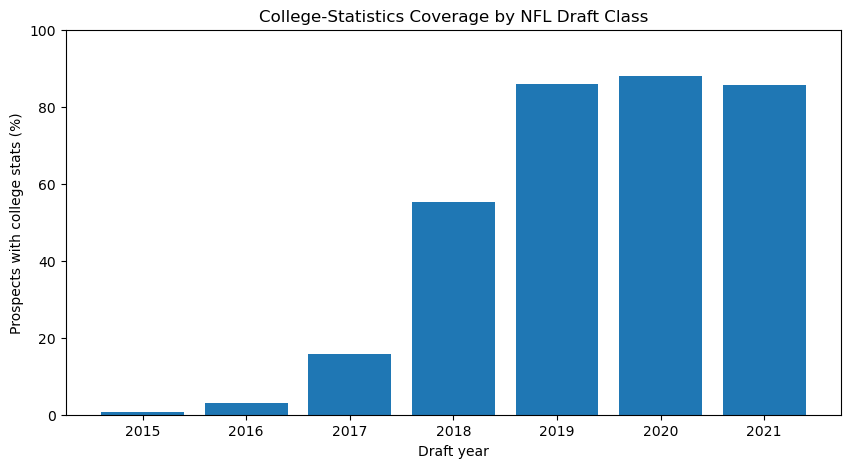

In [8]:
# Visualize recent coverage
recent_coverage = coverage_by_class.query("draft_year >= 2015").copy()

plt.figure(figsize=(10, 5))
plt.bar(recent_coverage["draft_year"], recent_coverage["college_coverage"] * 100)
plt.title("College-Statistics Coverage by NFL Draft Class")
plt.xlabel("Draft year")
plt.ylabel("Prospects with college stats (%)")
plt.ylim(0, 100)
plt.show()

## 6. Construct the ordered target

The source `round` column is missing for undrafted prospects. We map:

- Round 1 → target 0
- ...
- Round 7 → target 6
- Undrafted → target 7

The numeric target is zero-indexed for XGBoost, but all reporting uses football-friendly labels.

In [9]:
prospects = prospects.copy()
prospects["draft_class"] = prospects["round"].fillna(8).astype(int)
prospects["target"] = prospects["draft_class"] - 1
prospects["draft_outcome"] = prospects["target"].map(dict(enumerate(CLASS_NAMES)))

assert prospects["draft_class"].between(1, 8).all()
assert prospects["target"].between(0, 7).all()

prospects[["player_name", "round", "overall", "draft_class", "draft_outcome"]].head(15)

,player_name,round,overall,draft_class,draft_outcome
0,Bubba Smith,1.000,1.000,1,Round 1
1,Clinton Jones,1.000,2.000,1,Round 1
2,Steve Spurrier,1.000,3.000,1,Round 1
3,Bob Griese,1.000,4.000,1,Round 1
4,George Webster,1.000,5.000,1,Round 1
5,Floyd Little,1.000,6.000,1,Round 1
6,Mel Farr,1.000,7.000,1,Round 1
7,Gene Washington,1.000,8.000,1,Round 1
8,Bob Hyland,1.000,9.000,1,Round 1
9,Loyd Phillips,1.000,10.000,1,Round 1


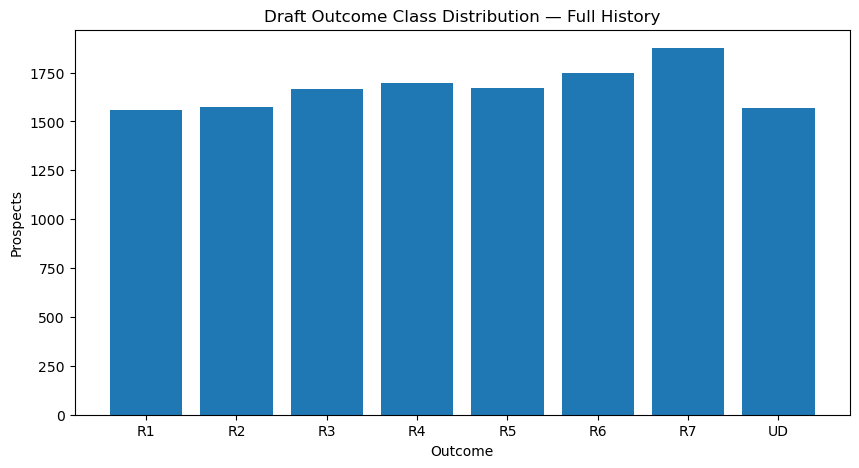

,class,count,share
0,Round 1,1558,0.117
1,Round 2,1574,0.118
2,Round 3,1666,0.125
3,Round 4,1694,0.127
4,Round 5,1672,0.125
5,Round 6,1749,0.131
6,Round 7,1875,0.140
7,Undrafted,1566,0.117


In [10]:
class_counts_all = (
    prospects["target"]
    .value_counts()
    .sort_index()
    .reindex(CLASS_INDEX, fill_value=0)
)

plt.figure(figsize=(10, 5))
plt.bar(CLASS_SHORT, class_counts_all.values)
plt.title("Draft Outcome Class Distribution — Full History")
plt.xlabel("Outcome")
plt.ylabel("Prospects")
plt.show()

pd.DataFrame({
    "class": CLASS_NAMES,
    "count": class_counts_all.values,
    "share": class_counts_all.values / class_counts_all.values.sum(),
})

## 7. Clean the college-stat table

Exact duplicate rows are removed before feature aggregation so repeated records do not distort player summaries.

In [11]:
# Remove exact duplicated college-stat observations
college_before = len(college)
college_clean = college.drop_duplicates().copy()
college_after = len(college_clean)

print(f"College rows before deduplication: {college_before:,}")
print(f"College rows after deduplication:  {college_after:,}")
print(f"Removed: {college_before - college_after:,}")

College rows before deduplication: 66,672
College rows after deduplication:  64,172
Removed: 2,500


In [12]:
# Inspect the most common college statistics
stat_counts = (
    college_clean["statistic"]
    .value_counts()
    .rename_axis("statistic")
    .reset_index(name="observations")
)

display(stat_counts.head(40))

,statistic,observations
0,Interceptions,3425
1,Total Tackles,3137
2,Assist Tackles,3137
3,Passes Defended,3137
4,Sacks,3137
5,Forced Fumbles,3137
6,Interception Yards,3137
7,Interception Touchdowns,3137
8,Solo Tackles,3137
9,Receiving Touchdowns,1889


# Part II — Exploratory analysis

## 8. Recent modeling cohort

The main experiment uses 2018–2021, where college-stat linkage is substantially stronger. Undrafted prospects are retained.

In [13]:
recent = prospects.query("2018 <= draft_year <= 2021").copy()

recent_counts = (
    recent.groupby(["draft_year", "target"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_INDEX, fill_value=0)
)
recent_counts.columns = CLASS_SHORT
recent_counts

,R1,R2,R3,R4,R5,R6,R7,UD
draft_year,,,,,,,,
2018,32,32,36,37,37,44,38,123
2019,32,32,38,36,35,41,40,146
2020,32,32,42,40,33,35,41,92
2021,32,32,41,39,40,44,31,107


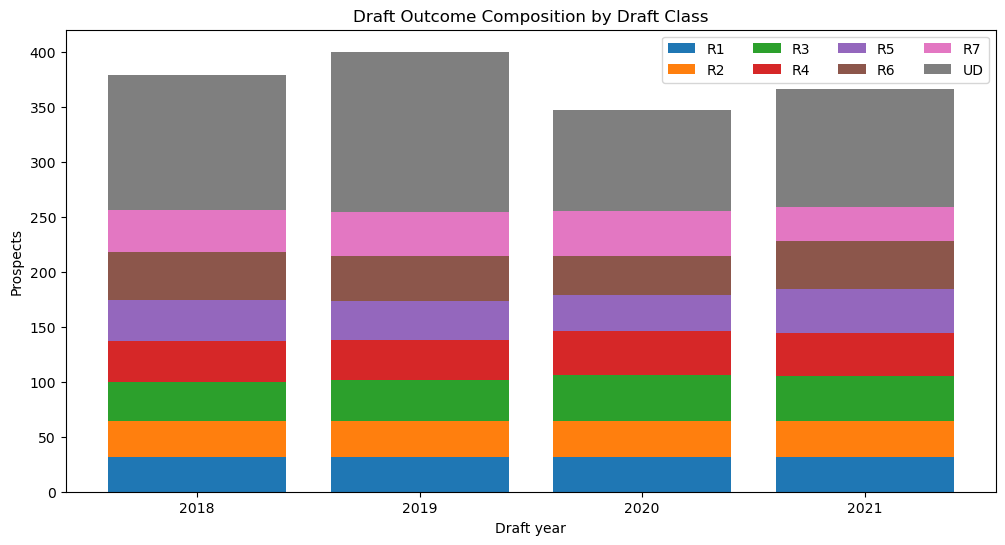

In [14]:
plt.figure(figsize=(12, 6))
bottom = np.zeros(len(recent_counts))
x = np.arange(len(recent_counts.index))

for col in recent_counts.columns:
    vals = recent_counts[col].values
    plt.bar(x, vals, bottom=bottom, label=col)
    bottom += vals

plt.xticks(x, recent_counts.index)
plt.title("Draft Outcome Composition by Draft Class")
plt.xlabel("Draft year")
plt.ylabel("Prospects")
plt.legend(ncol=4)
plt.show()

## 9. Position × draft outcome

This normalized heatmap shows how draft outcomes vary within positions while controlling for different position sample sizes.

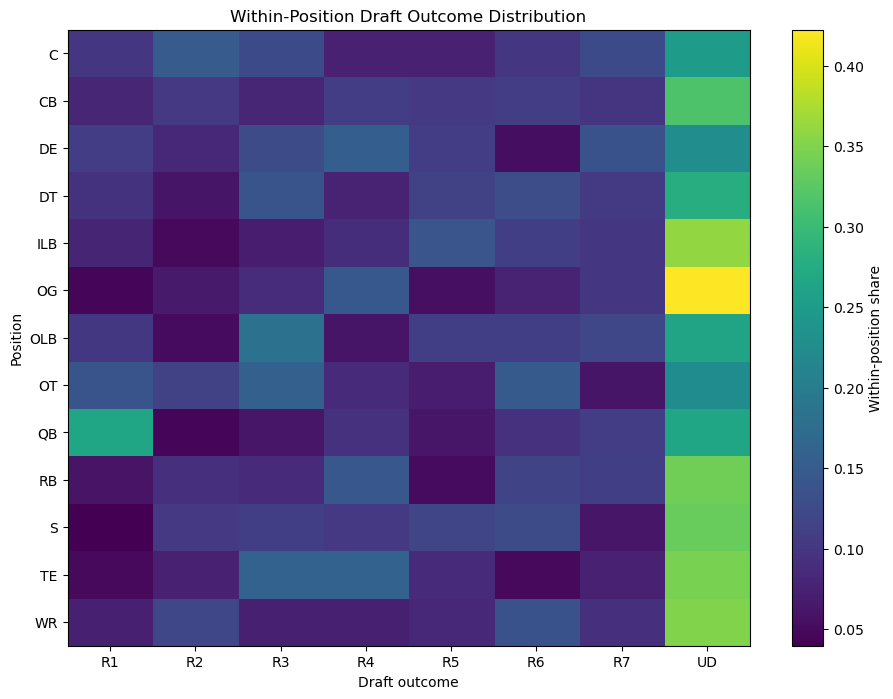

In [15]:
position_round = pd.crosstab(
    recent["pos_abbr"].fillna("Unknown"),
    recent["target"],
    normalize="index",
).reindex(columns=CLASS_INDEX, fill_value=0)

position_n = recent["pos_abbr"].value_counts()
keep_positions = position_n[position_n >= 20].index
position_round = position_round.loc[position_round.index.intersection(keep_positions)]

fig, ax = plt.subplots(figsize=(11, 8))
img = ax.imshow(position_round.values, aspect="auto")
ax.set_xticks(CLASS_INDEX)
ax.set_xticklabels(CLASS_SHORT)
ax.set_yticks(np.arange(len(position_round.index)))
ax.set_yticklabels(position_round.index)
ax.set_title("Within-Position Draft Outcome Distribution")
ax.set_xlabel("Draft outcome")
ax.set_ylabel("Position")
fig.colorbar(img, ax=ax, label="Within-position share")
plt.show()

# Part III — Feature engineering

## 10. Longitudinal college production

For every player/statistic combination we engineer:

- `last__*`: most recent observed season
- `mean__*`: average across observed seasons
- `max__*`: peak observed season
- `trend__*`: most recent minus earliest observed value

We also keep the number of observed college seasons and first/final season.

In [16]:
# Prepare long-form statistics
college_model = (
    college_clean
    .dropna(subset=["player_id", "season", "statistic", "value"])
    .copy()
)

college_model["season"] = college_model["season"].astype(int)

# Most recent value for each player/statistic
last_stats = (
    college_model
    .sort_values(["player_id", "statistic", "season"])
    .drop_duplicates(["player_id", "statistic"], keep="last")
    .pivot(index="player_id", columns="statistic", values="value")
    .add_prefix("college_last__")
)

# Earliest value for trend construction
first_stats = (
    college_model
    .sort_values(["player_id", "statistic", "season"])
    .drop_duplicates(["player_id", "statistic"], keep="first")
    .pivot(index="player_id", columns="statistic", values="value")
)

# Mean and peak values
mean_stats = (
    college_model
    .pivot_table(index="player_id", columns="statistic", values="value", aggfunc="mean")
    .add_prefix("college_mean__")
)

max_stats = (
    college_model
    .pivot_table(index="player_id", columns="statistic", values="value", aggfunc="max")
    .add_prefix("college_max__")
)

trend_stats = last_stats.copy()
trend_stats.columns = trend_stats.columns.str.replace(
    "college_last__", "", regex=False
)
trend_stats = trend_stats.subtract(first_stats, fill_value=np.nan)
trend_stats = trend_stats.add_prefix("college_trend__")

college_meta = (
    college_model
    .groupby("player_id")
    .agg(
        college_seasons_observed=("season", "nunique"),
        final_college_season=("season", "max"),
        first_college_season=("season", "min"),
    )
)

college_features = (
    college_meta
    .join(last_stats, how="outer")
    .join(mean_stats, how="outer")
    .join(max_stats, how="outer")
    .join(trend_stats, how="outer")
    .reset_index()
)

print("Engineered college feature table:", college_features.shape)
college_features.head()

Engineered college feature table: (1265, 236)


,player_id,college_seasons_observed,final_college_season,first_college_season,college_last__Assist Tackles,college_last__Completion Percentage,college_last__Completions,college_last__Extra Points Made,college_last__FGM 1-19 yards,college_last__FGM 20-29 yards,college_last__FGM 30-39 yards,college_last__FGM 40-49 yards,college_last__FGM 50+ yards,college_last__Field Goal Attempts,college_last__Field Goal Made,college_last__Field Goal Percentage,college_last__Field Goals,college_last__Forced Fumbles,college_last__Gross Average Punt Yards,college_last__Interception Touchdowns,college_last__Interception Yards,college_last__Interceptions,college_last__Kick Extra Points,college_last__Kick Return Touchdowns,college_last__Kick Return Yards,college_last__Kick Returns,college_last__Long Field Goal Made,college_last__Long Kick Return,college_last__Long Punt,college_last__Long Punt Return,college_last__Long Reception,college_last__Long Rushing,college_last__Longest Pass,college_last__Passer Rating,college_last__Passes Defended,college_last__Passing Attempts,college_last__Passing Touchdowns,college_last__Passing Yards,college_last__Punt Return Fair Catches,college_last__Punt Return Touchdowns,college_last__Punt Return Yards,college_last__Punt Returns,college_last__Punt Yards,college_last__Punts,college_last__Receiving Touchdowns,college_last__Receiving Yards,college_last__Receptions,college_last__Return Touchdowns,college_last__Rushing Attempts,college_last__Rushing Touchdowns,college_last__Rushing Yards,college_last__Sacks,college_last__Solo Tackles,college_last__Total Kicking Points,college_last__Total Points,college_last__Total Sacks,college_last__Total Tackles,college_last__Total Touchdowns,college_last__Total Two Point Conversions,college_last__Yards Per Pass Attempt,college_last__Yards Per Reception,college_last__Yards Per Rush Attempt,college_mean__Assist Tackles,college_mean__Completion Percentage,college_mean__Completions,college_mean__Extra Points Made,college_mean__FGM 1-19 yards,college_mean__FGM 20-29 yards,college_mean__FGM 30-39 yards,college_mean__FGM 40-49 yards,...,college_max__Rushing Yards,college_max__Sacks,college_max__Solo Tackles,college_max__Total Kicking Points,college_max__Total Points,college_max__Total Sacks,college_max__Total Tackles,college_max__Total Touchdowns,college_max__Total Two Point Conversions,college_max__Yards Per Pass Attempt,college_max__Yards Per Reception,college_max__Yards Per Rush Attempt,college_trend__Assist Tackles,college_trend__Completion Percentage,college_trend__Completions,college_trend__Extra Points Made,college_trend__FGM 1-19 yards,college_trend__FGM 20-29 yards,college_trend__FGM 30-39 yards,college_trend__FGM 40-49 yards,college_trend__FGM 50+ yards,college_trend__Field Goal Attempts,college_trend__Field Goal Made,college_trend__Field Goal Percentage,college_trend__Field Goals,college_trend__Forced Fumbles,college_trend__Gross Average Punt Yards,college_trend__Interception Touchdowns,college_trend__Interception Yards,college_trend__Interceptions,college_trend__Kick Extra Points,college_trend__Kick Return Touchdowns,college_trend__Kick Return Yards,college_trend__Kick Returns,college_trend__Long Field Goal Made,college_trend__Long Kick Return,college_trend__Long Punt,college_trend__Long Punt Return,college_trend__Long Reception,college_trend__Long Rushing,college_trend__Longest Pass,college_trend__Passer Rating,college_trend__Passes Defended,college_trend__Passing Attempts,college_trend__Passing Touchdowns,college_trend__Passing Yards,college_trend__Punt Return Fair Catches,college_trend__Punt Return Touchdowns,college_trend__Punt Return Yards,college_trend__Punt Returns,college_trend__Punt Yards,college_trend__Punts,college_trend__Receiving Touchdowns,college_trend__Receiving Yards,college_trend__Receptions,college_trend__Return Touchdowns,college_trend__Rushing Attempts,college_trend__Rushing Touchdowns,college_trend__Rushing Yards,college_trend__Sacks,college_trend__Solo Tackle

## 11. Advanced college QBR features

For quarterbacks, QBR provides efficiency and EPA-style information beyond traditional box scores. The unreliable source `age` field is intentionally excluded.

In [17]:
qbr_metrics = [
    "total_qbr",
    "points_added",
    "qb_plays",
    "total_epa",
    "pass",
    "run",
    "exp_sack",
    "penalty",
    "raw_qbr",
    "sack",
]

qbr_clean = qbr.drop(columns=["age"], errors="ignore").copy()
qbr_clean = qbr_clean.sort_values(["guid", "season"])

qbr_last = (
    qbr_clean
    .drop_duplicates("guid", keep="last")
    .set_index("guid")[qbr_metrics]
    .add_prefix("qbr_last__")
)

qbr_first_raw = (
    qbr_clean
    .drop_duplicates("guid", keep="first")
    .set_index("guid")[qbr_metrics]
)

qbr_mean = (
    qbr_clean.groupby("guid")[qbr_metrics]
    .mean()
    .add_prefix("qbr_mean__")
)

qbr_max = (
    qbr_clean.groupby("guid")[qbr_metrics]
    .max()
    .add_prefix("qbr_max__")
)

qbr_trend = qbr_last.copy()
qbr_trend.columns = qbr_trend.columns.str.replace("qbr_last__", "", regex=False)
qbr_trend = qbr_trend.subtract(qbr_first_raw, fill_value=np.nan)
qbr_trend = qbr_trend.add_prefix("qbr_trend__")

qbr_meta = (
    qbr_clean.groupby("guid")
    .agg(
        qbr_seasons_observed=("season", "nunique"),
        qbr_final_season=("season", "max"),
    )
)

qbr_features = (
    qbr_meta
    .join(qbr_last)
    .join(qbr_mean)
    .join(qbr_max)
    .join(qbr_trend)
    .reset_index()
)

print("Engineered QBR feature table:", qbr_features.shape)
qbr_features.head()

Engineered QBR feature table: (1076, 43)


,guid,qbr_seasons_observed,qbr_final_season,qbr_last__total_qbr,qbr_last__points_added,qbr_last__qb_plays,qbr_last__total_epa,qbr_last__pass,qbr_last__run,qbr_last__exp_sack,qbr_last__penalty,qbr_last__raw_qbr,qbr_last__sack,qbr_mean__total_qbr,qbr_mean__points_added,qbr_mean__qb_plays,qbr_mean__total_epa,qbr_mean__pass,qbr_mean__run,qbr_mean__exp_sack,qbr_mean__penalty,qbr_mean__raw_qbr,qbr_mean__sack,qbr_max__total_qbr,qbr_max__points_added,qbr_max__qb_plays,qbr_max__total_epa,qbr_max__pass,qbr_max__run,qbr_max__exp_sack,qbr_max__penalty,qbr_max__raw_qbr,qbr_max__sack,qbr_trend__total_qbr,qbr_trend__points_added,qbr_trend__qb_plays,qbr_trend__total_epa,qbr_trend__pass,qbr_trend__run,qbr_trend__exp_sack,qbr_trend__penalty,qbr_trend__raw_qbr,qbr_trend__sack
0,003a73ca8b421fd25b8e00f4793c1a98,2,2017,58.500,-5.200,355,10.100,22.000,-4.500,-8.800,3.000,46.200,-10.400,58.200,-1.150,441.500,17.700,31.900,-2.650,-12.850,3.000,48.850,-14.500,58.500,2.900,528,25.300,41.800,-0.800,-8.800,3.000,51.500,-10.400,0.600,-8.100,-173,-15.200,-19.800,-3.700,8.100,0.000,-5.300,8.200
1,009375da6777aaa5ecf9389aa9afb7ec,1,2011,26.600,-31.700,437,-8.600,3.900,-3.100,-11.100,2.500,32.000,-12.100,26.600,-31.700,437.000,-8.600,3.900,-3.100,-11.100,2.500,32.000,-12.100,26.600,-31.700,437,-8.600,3.900,-3.100,-11.100,2.500,32.000,-12.100,0.000,0.000,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,00be888b38b5e26fc4b4d18aca23e7b7,1,2004,84.100,56.600,454,61.200,70.900,-6.200,-5.400,2.700,78.500,-6.100,84.100,56.600,454.000,61.200,70.900,-6.200,-5.400,2.700,78.500,-6.100,84.100,56.600,454,61.200,70.900,-6.200,-5.400,2.700,78.500,-6.100,0.000,0.000,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,00c35dd180b2dabd28c7c594a4cdfea0,1,2017,71.000,39.800,593,60.800,69.500,4.500,-18.700,5.500,66.800,-18.700,71.000,39.800,593.000,60.800,69.500,4.500,-18.700,5.500,66.800,-18.700,71.000,39.800,593,60.800,69.500,4.500,-18.700,5.500,66.800,-18.700,0.000,0.000,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,010203e701620cf1aaae5e183e3469ef,1,2007,31.700,-23.600,313,-6.500,4.000,-1.300,-9.900,0.500,31.400,-9.900,31.700,-23.600,313.000,-6.500,4.000,-1.300,-9.900,0.500,31.400,-9.900,31.700,-23.600,313,-6.500,4.000,-1.300,-9.900,0.500,31.400,-9.900,0.000,0.000,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## 12. Scouting-report NLP

The four free-text scouting fields are concatenated into a single document per prospect. The modeling pipeline later transforms this with TF-IDF, bigrams, and Truncated SVD latent dimensions.

In [18]:
profile_text = profiles[
    ["player_id", "text1", "text2", "text3", "text4"]
].copy()

text_cols = ["text1", "text2", "text3", "text4"]

profile_text["scouting_text"] = (
    profile_text[text_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

profile_text["has_scouting_text"] = (
    profile_text["scouting_text"].str.len() > 0
).astype(int)

profile_text = profile_text[["player_id", "scouting_text", "has_scouting_text"]]

profile_text.head()

,player_id,scouting_text,has_scouting_text
0,23590,,0
1,23591,,0
2,23592,,0
3,23593,,0
4,23594,,0


## 13. Assemble the modeling table

The draft-prospect table is the spine. We join college production by `player_id`, scouting text by `player_id`, and QBR by ESPN `guid`.

In [19]:
model_df = (
    prospects
    .merge(profile_text, on="player_id", how="left")
    .merge(college_features, on="player_id", how="left")
    .merge(qbr_features, on="guid", how="left")
    .copy()
)

model_df["scouting_text"] = model_df["scouting_text"].fillna("")
model_df["has_scouting_text"] = model_df["has_scouting_text"].fillna(0)
model_df["scouting_text_length"] = model_df["scouting_text"].str.split().str.len().fillna(0)
model_df["years_from_final_college_season"] = (
    model_df["draft_year"] - model_df["final_college_season"]
)
model_df["is_qb"] = (model_df["pos_abbr"] == "QB").astype(int)
model_df = model_df.query("2018 <= draft_year <= 2021").copy()

print("Modeling cohort:", model_df.shape)
display(
    model_df.groupby("draft_year")
    .agg(
        prospects=("player_id", "size"),
        drafted=("overall", lambda s: s.notna().sum()),
        undrafted=("overall", lambda s: s.isna().sum()),
        scouting_text_coverage=("has_scouting_text", "mean"),
        college_feature_coverage=("college_seasons_observed", lambda s: s.notna().mean()),
    )
)

Modeling cohort: (1492, 309)


,prospects,drafted,undrafted,scouting_text_coverage,college_feature_coverage
draft_year,,,,,
2018,379,256,123,0.958,0.551
2019,400,254,146,0.890,0.860
2020,347,255,92,0.896,0.879
2021,366,259,107,0.956,0.855


## 14. Leakage audit

### Never used as predictors

- `overall`
- `pick`
- `round`
- `team`
- `team_abbr`
- trade fields
- derived target columns

### Legal but target-adjacent consensus variables

- `grade`
- `ovr_rk`
- `pos_rk`

These are known before the draft, but they summarize public draft consensus. They are therefore added only in the **full pre-draft** feature set so we can measure their incremental value rather than hiding them inside the base model.

In [20]:
college_feature_cols = [c for c in model_df.columns if c.startswith("college_")]
qbr_feature_cols = [c for c in model_df.columns if c.startswith("qbr_")]

physical_numeric = [
    "height",
    "weight",
    "has_scouting_text",
    "scouting_text_length",
    "years_from_final_college_season",
    "is_qb",
]

categorical_features = ["pos_abbr", "school"]
consensus_features = ["grade", "ovr_rk", "pos_rk"]
text_feature = "scouting_text"

numeric_production = sorted(set(
    physical_numeric + college_feature_cols + qbr_feature_cols
))

print(f"Production/physical numeric features: {len(numeric_production):,}")
print(f"Categorical features: {len(categorical_features):,}")
print(f"Consensus features: {len(consensus_features):,}")

Production/physical numeric features: 281
Categorical features: 2
Consensus features: 3


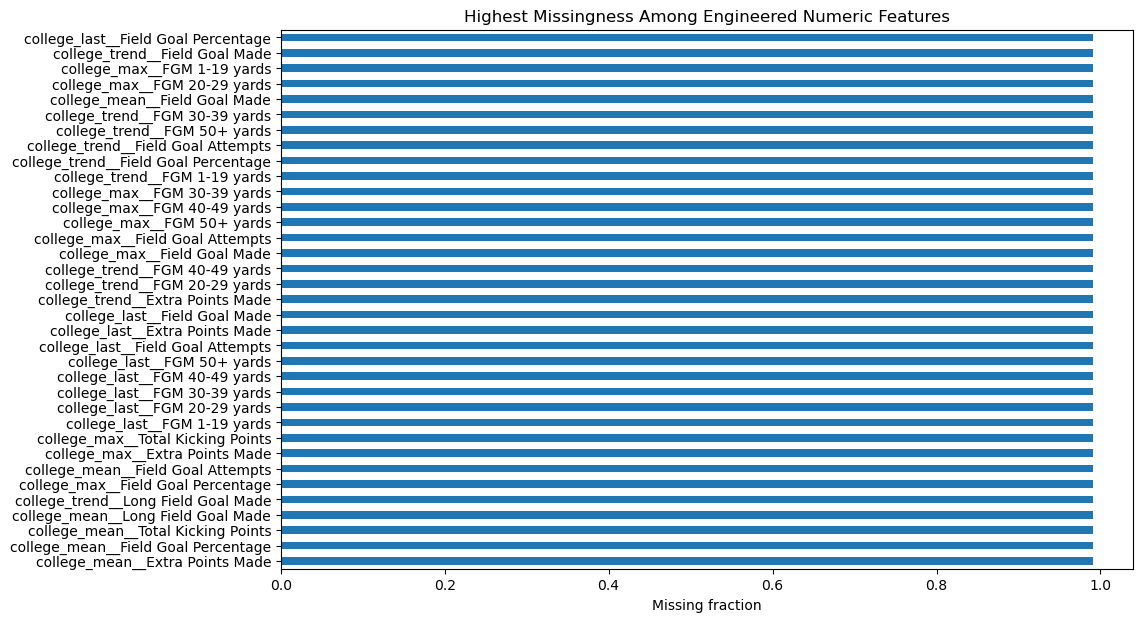

In [21]:
missingness = (
    model_df[numeric_production + consensus_features]
    .isna().mean().sort_values(ascending=False)
)

plt.figure(figsize=(11, 7))
missingness.head(35).sort_values().plot(kind="barh")
plt.title("Highest Missingness Among Engineered Numeric Features")
plt.xlabel("Missing fraction")
plt.ylabel("")
plt.show()

# Part IV — Time-aware split and preprocessing

## 15. Hold out the 2021 draft class

In [22]:
TRAIN_YEARS = [2018, 2019, 2020]
TEST_YEAR = 2021

train_df = model_df[model_df["draft_year"].isin(TRAIN_YEARS)].copy()
test_df = model_df[model_df["draft_year"] == TEST_YEAR].copy()

y_train = train_df["target"].astype(int)
y_test = test_df["target"].astype(int)
groups_train = train_df["draft_year"].astype(int)

print("Train:", train_df.shape, sorted(train_df["draft_year"].unique()))
print("Test: ", test_df.shape, sorted(test_df["draft_year"].unique()))

Train: (1126, 309) [np.int64(2018), np.int64(2019), np.int64(2020)]
Test:  (366, 309) [np.int64(2021)]


## 16. Advanced mixed-data preprocessing

### Numeric
- median imputation
- explicit missingness indicators
- robust scaling

### Categorical
- most-frequent imputation
- rare-category grouping
- one-hot encoding

### Text
- TF-IDF
- unigrams + bigrams
- sublinear term frequency
- Truncated SVD
- latent-feature scaling

Every transformation remains inside the sklearn pipeline so it is refit independently in each validation fold.

In [23]:
def build_preprocessor(
    numeric_cols,
    categorical_cols,
    include_text=True,
    n_text_components=25,
):
    transformers = []

    if numeric_cols:
        numeric_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", RobustScaler()),
        ])
        transformers.append(("numeric", numeric_pipe, numeric_cols))

    if categorical_cols:
        categorical_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=5,
                    sparse_output=True,
                ),
            ),
        ])
        transformers.append(("categorical", categorical_pipe, categorical_cols))

    if include_text:
        text_pipe = Pipeline([
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    stop_words="english",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=1500,
                    sublinear_tf=True,
                ),
            ),
            ("svd", TruncatedSVD(
                n_components=n_text_components,
                random_state=RANDOM_STATE,
            )),
            ("scale", StandardScaler()),
        ])
        transformers.append(("text", text_pipe, text_feature))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.30,
    )

## 17. Three information sets for ablation

In [24]:
FEATURE_SETS = {
    "production": {
        "numeric": numeric_production,
        "categorical": categorical_features,
        "text": False,
    },
    "production_plus_text": {
        "numeric": numeric_production,
        "categorical": categorical_features,
        "text": True,
    },
    "full_predraft": {
        "numeric": numeric_production + consensus_features,
        "categorical": categorical_features,
        "text": True,
    },
}

def columns_for_feature_set(name):
    cfg = FEATURE_SETS[name]
    cols = cfg["numeric"] + cfg["categorical"]
    if cfg["text"]:
        cols = cols + [text_feature]
    return list(dict.fromkeys(cols))

# Part V — Ordinal-aware evaluation

## 18. Metric helpers

The key distinction from ordinary multiclass classification is **distance**. Missing by one round is less severe than missing by five rounds.

In [25]:
def expected_round_from_proba(proba):
    return np.asarray(proba) @ ROUND_VALUES

def normalized_entropy(proba):
    p = np.clip(np.asarray(proba), 1e-12, 1.0)
    entropy = -(p * np.log(p)).sum(axis=1)
    return entropy / np.log(p.shape[1])

def align_probability_columns(model, proba):
    out = np.zeros((len(proba), N_CLASSES), dtype=float)
    for j, cls in enumerate(model.classes_):
        out[:, int(cls)] = proba[:, j]
    row_sum = out.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    return out / row_sum

def classification_metrics(y_true, pred, proba, label=None):
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    proba = np.asarray(proba)
    distance = np.abs(pred - y_true)
    expected = expected_round_from_proba(proba)

    return pd.Series({
        "model": label,
        "exact_accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "macro_F1": f1_score(y_true, pred, average="macro", zero_division=0),
        "weighted_F1": f1_score(y_true, pred, average="weighted", zero_division=0),
        "log_loss": log_loss(y_true, proba, labels=CLASS_INDEX),
        "mean_round_error": distance.mean(),
        "within_1_round": (distance <= 1).mean(),
        "within_2_rounds": (distance <= 2).mean(),
        "quadratic_kappa": cohen_kappa_score(y_true, pred, weights="quadratic"),
        "top_2_accuracy": top_k_accuracy_score(y_true, proba, k=2, labels=CLASS_INDEX),
        "expected_round_MAE": np.abs((y_true + 1) - expected).mean(),
    })

# Part VI — Baseline model comparison

## 19. Dummy, multinomial logistic regression, random forest, and XGBoost

Class imbalance is handled with balanced class weights or balanced sample weights where supported.

In [26]:
feature_set_name = "full_predraft"
cfg = FEATURE_SETS[feature_set_name]
feature_cols = columns_for_feature_set(feature_set_name)
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

baseline_results = []
baseline_models = {}
baseline_probabilities = {}

In [27]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_proba = align_probability_columns(
    dummy,
    dummy.predict_proba(np.zeros((len(y_test), 1)))
)
dummy_pred = dummy_proba.argmax(axis=1)
baseline_results.append(classification_metrics(y_test, dummy_pred, dummy_proba, "Dummy prior"))

In [28]:
logit_model = Pipeline([
    ("preprocess", build_preprocessor(cfg["numeric"], cfg["categorical"], include_text=True)),
    ("model", LogisticRegression(max_iter=4000, class_weight="balanced", C=0.5, solver="lbfgs")),
])
logit_model.fit(X_train, y_train)
logit_proba = align_probability_columns(
    logit_model.named_steps["model"],
    logit_model.predict_proba(X_test),
)
logit_pred = logit_proba.argmax(axis=1)
baseline_results.append(classification_metrics(y_test, logit_pred, logit_proba, "Multinomial Logistic"))
baseline_models["Multinomial Logistic"] = logit_model
baseline_probabilities["Multinomial Logistic"] = logit_proba

In [29]:
rf_model = Pipeline([
    ("preprocess", build_preprocessor(cfg["numeric"], cfg["categorical"], include_text=True)),
    ("model", RandomForestClassifier(
        n_estimators=700,
        min_samples_leaf=2,
        max_features=0.55,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])
rf_model.fit(X_train, y_train)
rf_proba = align_probability_columns(rf_model.named_steps["model"], rf_model.predict_proba(X_test))
rf_pred = rf_proba.argmax(axis=1)
baseline_results.append(classification_metrics(y_test, rf_pred, rf_proba, "Random Forest"))
baseline_models["Random Forest"] = rf_model
baseline_probabilities["Random Forest"] = rf_proba

In [30]:
xgb_default = Pipeline([
    ("preprocess", build_preprocessor(cfg["numeric"], cfg["categorical"], include_text=True)),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=N_CLASSES,
        eval_metric="mlogloss",
        n_estimators=650,
        learning_rate=0.04,
        max_depth=4,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.80,
        reg_alpha=0.05,
        reg_lambda=2.0,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

xgb_weights = compute_sample_weight(class_weight="balanced", y=y_train)
xgb_default.fit(X_train, y_train, model__sample_weight=xgb_weights)
xgb_default_proba = align_probability_columns(
    xgb_default.named_steps["model"],
    xgb_default.predict_proba(X_test),
)
xgb_default_pred = xgb_default_proba.argmax(axis=1)
baseline_results.append(classification_metrics(y_test, xgb_default_pred, xgb_default_proba, "XGBoost default"))
baseline_models["XGBoost default"] = xgb_default
baseline_probabilities["XGBoost default"] = xgb_default_proba

baseline_table = pd.DataFrame(baseline_results).set_index("model").sort_values(["mean_round_error", "log_loss"])
baseline_table

,exact_accuracy,balanced_accuracy,macro_F1,weighted_F1,log_loss,mean_round_error,within_1_round,within_2_rounds,quadratic_kappa,top_2_accuracy,expected_round_MAE
model,,,,,,,,,,,
XGBoost default,0.423,0.352,0.314,0.372,1.706,1.142,0.667,0.855,0.780,0.661,1.011
Random Forest,0.459,0.386,0.345,0.390,1.422,1.183,0.653,0.820,0.757,0.631,1.046
Multinomial Logistic,0.314,0.271,0.234,0.290,4.646,1.383,0.607,0.811,0.720,0.503,1.279
Dummy prior,0.292,0.125,0.057,0.132,1.981,2.776,0.377,0.497,0.000,0.413,2.111


# Part VII — Custom cumulative ordinal model

## 20. Explicitly model class ordering

Standard multiclass models treat every wrong label as categorically different. The custom ordinal model instead fits seven binary questions:

\[
P(Y > R1), P(Y > R2), ..., P(Y > R7)
\]

Those cumulative probabilities are converted into a valid 8-class probability distribution. This structure directly represents the ordering of draft outcomes.

In [31]:
class CumulativeOrdinalXGB:
    def __init__(self, n_classes, **xgb_params):
        self.n_classes = n_classes
        self.xgb_params = xgb_params
        self.models_ = []

    def fit(self, X, y):
        y = np.asarray(y)
        self.models_ = []
        for threshold in range(self.n_classes - 1):
            y_binary = (y > threshold).astype(int)
            model = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_jobs=-1,
                random_state=RANDOM_STATE,
                **self.xgb_params,
            )
            weights = compute_sample_weight(class_weight="balanced", y=y_binary)
            model.fit(X, y_binary, sample_weight=weights)
            self.models_.append(model)
        return self

    def predict_proba(self, X):
        gt = np.column_stack([m.predict_proba(X)[:, 1] for m in self.models_])
        gt = np.minimum.accumulate(gt, axis=1)

        proba = np.zeros((len(gt), self.n_classes), dtype=float)
        proba[:, 0] = 1.0 - gt[:, 0]
        for cls in range(1, self.n_classes - 1):
            proba[:, cls] = gt[:, cls - 1] - gt[:, cls]
        proba[:, -1] = gt[:, -1]

        proba = np.clip(proba, 0, None)
        row_sum = proba.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1
        return proba / row_sum

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

In [32]:
ordinal_preprocessor = build_preprocessor(cfg["numeric"], cfg["categorical"], include_text=True)
X_train_ord = ordinal_preprocessor.fit_transform(X_train)
X_test_ord = ordinal_preprocessor.transform(X_test)

ordinal_model = CumulativeOrdinalXGB(
    n_classes=N_CLASSES,
    n_estimators=550,
    learning_rate=0.04,
    max_depth=4,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.80,
    reg_alpha=0.05,
    reg_lambda=2.0,
)
ordinal_model.fit(X_train_ord, y_train)
ordinal_proba = ordinal_model.predict_proba(X_test_ord)
ordinal_pred = ordinal_proba.argmax(axis=1)
ordinal_metrics = classification_metrics(y_test, ordinal_pred, ordinal_proba, "Cumulative Ordinal XGBoost")
ordinal_metrics.to_frame("value")

,value
model,Cumulative Ordinal XGBoost
exact_accuracy,0.454
balanced_accuracy,0.377
macro_F1,0.336
weighted_F1,0.397
log_loss,4.230
mean_round_error,1.087
within_1_round,0.686
within_2_rounds,0.850
quadratic_kappa,0.796


# Part VIII — Bayesian optimization

## 21. Optuna TPE with an ordinal-aware objective

Optuna's Tree-structured Parzen Estimator is a sequential Bayesian optimization method. Instead of tuning for exact accuracy, each trial minimizes **expected-round MAE** on grouped draft-year validation folds.

That objective uses the full class-probability distribution and respects ordinal distance.

In [33]:
N_TRIALS = 40

full_cfg = FEATURE_SETS["full_predraft"]
full_cols = columns_for_feature_set("full_predraft")
X_opt = train_df[full_cols].copy()
y_opt = y_train.copy()
groups_opt = groups_train.copy()
group_cv = GroupKFold(n_splits=len(TRAIN_YEARS))

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1100, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 30.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 1.00),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),
    }

    fold_errors = []
    for train_idx, valid_idx in group_cv.split(X_opt, y_opt, groups_opt):
        X_fold_train = X_opt.iloc[train_idx]
        X_fold_valid = X_opt.iloc[valid_idx]
        y_fold_train = y_opt.iloc[train_idx]
        y_fold_valid = y_opt.iloc[valid_idx]

        fold_model = Pipeline([
            ("preprocess", build_preprocessor(full_cfg["numeric"], full_cfg["categorical"], include_text=True)),
            ("model", XGBClassifier(
                **params,
                objective="multi:softprob",
                num_class=N_CLASSES,
                eval_metric="mlogloss",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ])

        fold_weights = compute_sample_weight(class_weight="balanced", y=y_fold_train)
        fold_model.fit(X_fold_train, y_fold_train, model__sample_weight=fold_weights)
        proba = align_probability_columns(
            fold_model.named_steps["model"],
            fold_model.predict_proba(X_fold_valid),
        )
        expected = expected_round_from_proba(proba)
        fold_errors.append(np.mean(np.abs((y_fold_valid.to_numpy() + 1) - expected)))

    return float(np.mean(fold_errors))

In [34]:
study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="nfl_draft_round_xgboost",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"Best grouped-CV expected-round MAE: {study.best_value:.4f}")
display(pd.Series(study.best_params, name="value").to_frame())

[I 2026-08-20 20:41:35,516] A new study created in memory with name: nfl_draft_round_xgboost


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-08-20 20:41:43,630] Trial 0 finished with value: 0.9687258106648017 and parameters: {'n_estimators': 600, 'learning_rate': 0.13125830316209655, 'max_depth': 6, 'min_child_weight': 7.6611007077713635, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.6201975341512912, 'gamma': 0.2904180608409973, 'reg_alpha': 1.5741890047456624, 'reg_lambda': 0.667761551174708}. Best is trial 0 with value: 0.9687258106648017.
[I 2026-08-20 20:42:02,269] Trial 1 finished with value: 1.0474064489633423 and parameters: {'n_estimators': 900, 'learning_rate': 0.010573268083515799, 'max_depth': 7, 'min_child_weight': 16.967533607196547, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6318212352431953, 'gamma': 0.9170225492671691, 'reg_alpha': 0.0006690421166498799, 'reg_lambda': 0.29229052129200933}. Best is trial 0 with value: 0.9687258106648017.
[I 2026-08-20 20:42:11,118] Trial 2 finished with value: 1.082053760482786 and parameters: {'n_estimators': 600, 'learning_rate': 0.022004527434

,value
n_estimators,900.000
learning_rate,0.048
max_depth,6.000
min_child_weight,2.105
subsample,0.892
colsample_bytree,0.741
gamma,0.012
reg_alpha,0.000
reg_lambda,0.200


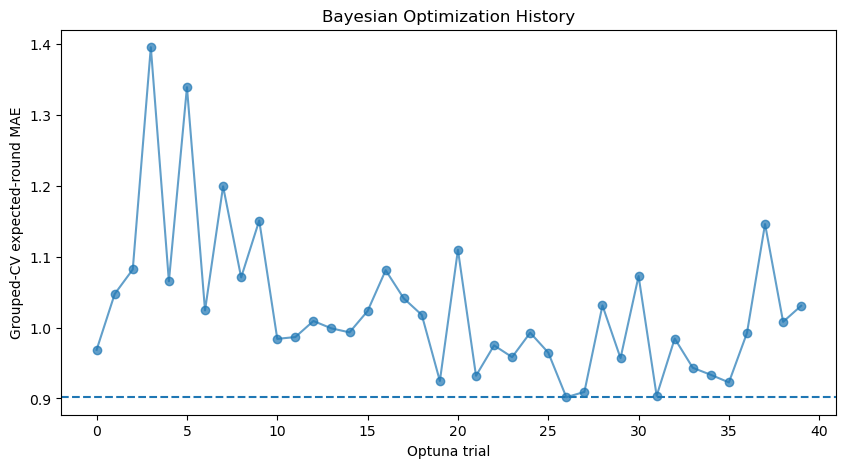

In [35]:
trials_df = study.trials_dataframe()
plt.figure(figsize=(10, 5))
plt.plot(trials_df["number"], trials_df["value"], marker="o", alpha=0.7)
plt.axhline(study.best_value, linestyle="--")
plt.title("Bayesian Optimization History")
plt.xlabel("Optuna trial")
plt.ylabel("Grouped-CV expected-round MAE")
plt.show()

## 22. Fit the final Bayesian-tuned model

Only after hyperparameters are selected from 2018–2020 grouped validation do we evaluate once on the untouched 2021 class.

In [36]:
best_params = study.best_params.copy()

final_model = Pipeline([
    ("preprocess", build_preprocessor(full_cfg["numeric"], full_cfg["categorical"], include_text=True)),
    ("model", XGBClassifier(
        **best_params,
        objective="multi:softprob",
        num_class=N_CLASSES,
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

X_train_full = train_df[full_cols].copy()
X_test_full = test_df[full_cols].copy()
final_weights = compute_sample_weight(class_weight="balanced", y=y_train)
final_model.fit(X_train_full, y_train, model__sample_weight=final_weights)

final_proba = align_probability_columns(
    final_model.named_steps["model"],
    final_model.predict_proba(X_test_full),
)
final_pred = final_proba.argmax(axis=1)
final_metrics = classification_metrics(y_test, final_pred, final_proba, "Bayesian-Tuned XGBoost")
final_metrics.to_frame("value")

,value
model,Bayesian-Tuned XGBoost
exact_accuracy,0.434
balanced_accuracy,0.354
macro_F1,0.315
weighted_F1,0.374
log_loss,1.984
mean_round_error,1.175
within_1_round,0.650
within_2_rounds,0.839
quadratic_kappa,0.773


# Part IX — Model comparison and diagnostic plots

## 23. Compare all model families

In [37]:
all_results = baseline_results + [ordinal_metrics, final_metrics]
comparison = (
    pd.DataFrame(all_results)
    .set_index("model")
    .sort_values(["mean_round_error", "log_loss"])
)
comparison

,exact_accuracy,balanced_accuracy,macro_F1,weighted_F1,log_loss,mean_round_error,within_1_round,within_2_rounds,quadratic_kappa,top_2_accuracy,expected_round_MAE
model,,,,,,,,,,,
Cumulative Ordinal XGBoost,0.454,0.377,0.336,0.397,4.230,1.087,0.686,0.850,0.796,0.653,1.033
XGBoost default,0.423,0.352,0.314,0.372,1.706,1.142,0.667,0.855,0.780,0.661,1.011
Bayesian-Tuned XGBoost,0.434,0.354,0.315,0.374,1.984,1.175,0.650,0.839,0.773,0.637,1.024
Random Forest,0.459,0.386,0.345,0.390,1.422,1.183,0.653,0.820,0.757,0.631,1.046
Multinomial Logistic,0.314,0.271,0.234,0.290,4.646,1.383,0.607,0.811,0.720,0.503,1.279
Dummy prior,0.292,0.125,0.057,0.132,1.981,2.776,0.377,0.497,0.000,0.413,2.111


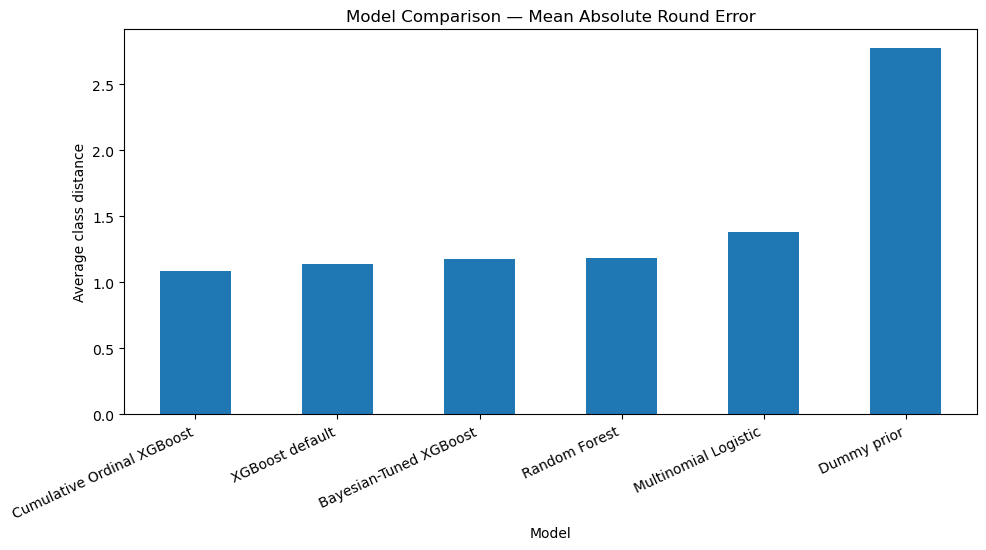

In [38]:
plt.figure(figsize=(11, 5))
comparison["mean_round_error"].sort_values().plot(kind="bar")
plt.title("Model Comparison — Mean Absolute Round Error")
plt.xlabel("Model")
plt.ylabel("Average class distance")
plt.xticks(rotation=25, ha="right")
plt.show()

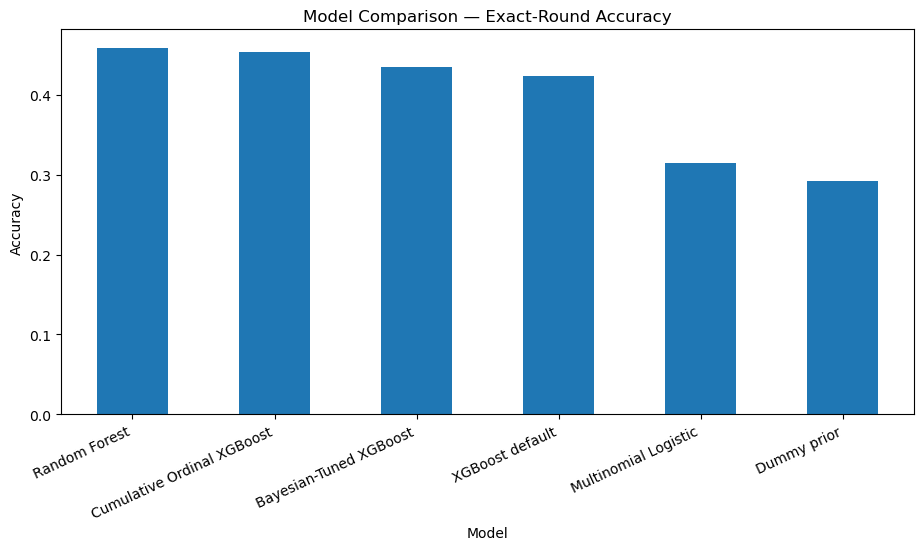

In [39]:
plt.figure(figsize=(11, 5))
comparison["exact_accuracy"].sort_values(ascending=False).plot(kind="bar")
plt.title("Model Comparison — Exact-Round Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
plt.show()

## 24. 8 × 8 confusion matrix

For an ordered target, a strong model should concentrate errors close to the diagonal.

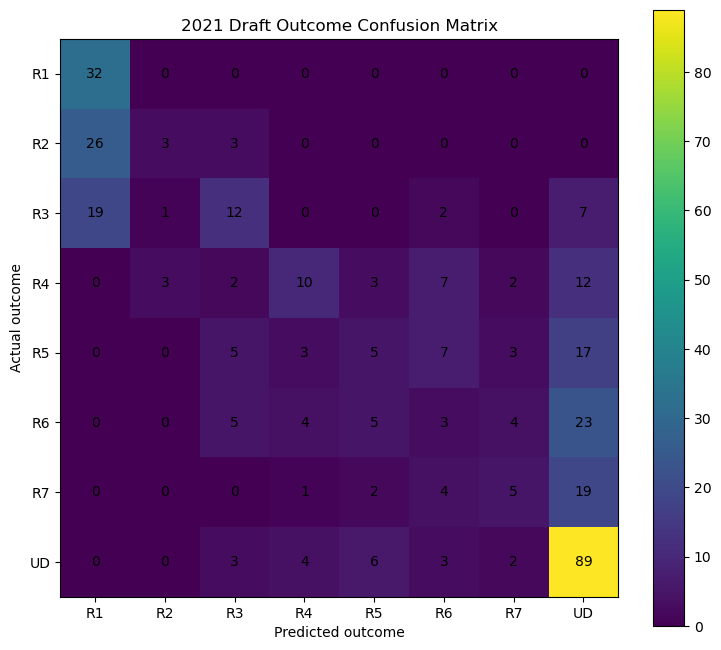

In [40]:
cm = confusion_matrix(y_test, final_pred, labels=CLASS_INDEX)
fig, ax = plt.subplots(figsize=(9, 8))
img = ax.imshow(cm)
ax.set_xticks(CLASS_INDEX)
ax.set_xticklabels(CLASS_SHORT)
ax.set_yticks(CLASS_INDEX)
ax.set_yticklabels(CLASS_SHORT)
ax.set_xlabel("Predicted outcome")
ax.set_ylabel("Actual outcome")
ax.set_title("2021 Draft Outcome Confusion Matrix")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center")
fig.colorbar(img, ax=ax)
plt.show()

In [41]:
report = classification_report(
    y_test,
    final_pred,
    labels=CLASS_INDEX,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T.loc[
    CLASS_NAMES,
    ["precision", "recall", "f1-score", "support"],
]
report_df

,precision,recall,f1-score,support
Round 1,0.416,1.000,0.587,32.000
Round 2,0.429,0.094,0.154,32.000
Round 3,0.400,0.293,0.338,41.000
Round 4,0.455,0.256,0.328,39.000
Round 5,0.238,0.125,0.164,40.000
Round 6,0.115,0.068,0.086,44.000
Round 7,0.312,0.161,0.213,31.000
Undrafted,0.533,0.832,0.650,107.000


## 25. How far away are the mistakes?

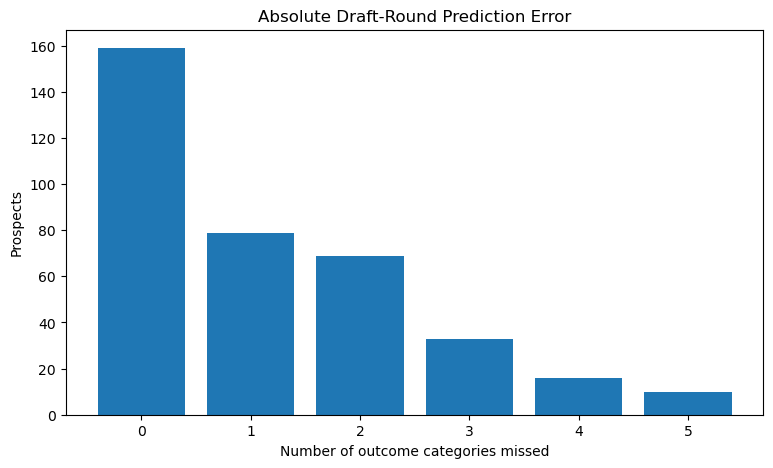

,distance,prospects,share
0,0,159,0.434
1,1,79,0.216
2,2,69,0.189
3,3,33,0.090
4,4,16,0.044
5,5,10,0.027


In [42]:
round_distance = np.abs(final_pred - y_test.to_numpy())
distance_counts = pd.Series(round_distance).value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.bar(distance_counts.index.astype(str), distance_counts.values)
plt.title("Absolute Draft-Round Prediction Error")
plt.xlabel("Number of outcome categories missed")
plt.ylabel("Prospects")
plt.show()

pd.DataFrame({
    "distance": distance_counts.index,
    "prospects": distance_counts.values,
    "share": distance_counts.values / distance_counts.values.sum(),
})

# Part X — Prospect-level probability analysis

## 26. Full probability distributions

Every prospect receives probabilities for Rounds 1–7 and Undrafted, plus an expected-round estimate and an entropy-based uncertainty score.

In [43]:
results_2021 = test_df[[
    "player_id", "player_name", "pos_abbr", "school",
    "round", "overall", "grade", "ovr_rk", "pos_rk", "target"
]].copy()

results_2021["actual_outcome"] = [CLASS_NAMES[i] for i in y_test]
results_2021["predicted_target"] = final_pred
results_2021["predicted_outcome"] = [CLASS_NAMES[i] for i in final_pred]
results_2021["expected_round"] = expected_round_from_proba(final_proba)
results_2021["class_distance"] = np.abs(results_2021["predicted_target"] - results_2021["target"])
results_2021["confidence"] = final_proba.max(axis=1)
results_2021["normalized_entropy"] = normalized_entropy(final_proba)

for idx, label in enumerate(CLASS_SHORT):
    results_2021[f"P_{label}"] = final_proba[:, idx]

results_2021.head()

,player_id,player_name,pos_abbr,school,round,overall,grade,ovr_rk,pos_rk,target,actual_outcome,predicted_target,predicted_outcome,expected_round,class_distance,confidence,normalized_entropy,P_R1,P_R2,P_R3,P_R4,P_R5,P_R6,P_R7,P_UD
12988,104734,Trevor Lawrence,QB,Clemson,1.000,1.000,97.000,1.000,1.000,0,Round 1,0,Round 1,1.000,0,1.000,0.001,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
12989,104933,Zach Wilson,QB,BYU,1.000,2.000,93.000,4.000,2.000,0,Round 1,0,Round 1,1.001,0,1.000,0.002,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
12990,104742,Trey Lance,QB,North Dakota State,1.000,3.000,92.000,9.000,3.000,0,Round 1,0,Round 1,1.000,0,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
12991,104760,Kyle Pitts,TE,Florida,1.000,4.000,94.000,2.000,1.000,0,Round 1,0,Round 1,1.001,0,0.999,0.003,0.999,0.000,0.000,0.000,0.000,0.000,0.000,0.000
12992,104737,Ja'Marr Chase,WR,LSU,1.000,5.000,94.000,3.000,1.000,0,Round 1,0,Round 1,1.002,0,0.999,0.006,0.999,0.001,0.000,0.000,0.000,0.000,0.000,0.000


In [44]:
probability_cols = [f"P_{x}" for x in CLASS_SHORT]
results_2021.sort_values("confidence", ascending=False).head(20)[[
    "player_name", "pos_abbr", "actual_outcome", "predicted_outcome",
    "expected_round", "confidence"
] + probability_cols]

,player_name,pos_abbr,actual_outcome,predicted_outcome,expected_round,confidence,P_R1,P_R2,P_R3,P_R4,P_R5,P_R6,P_R7,P_UD
12990,Trey Lance,QB,Round 1,Round 1,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
13000,Rashawn Slater,OT,Round 1,Round 1,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
12988,Trevor Lawrence,QB,Round 1,Round 1,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
13002,Mac Jones,QB,Round 1,Round 1,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
13005,Jaelan Phillips,DE,Round 1,Round 1,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
12998,Justin Fields,QB,Round 1,Round 1,1.001,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
12994,Penei Sewell,OT,Round 1,Round 1,1.001,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
12989,Zach Wilson,QB,Round 1,Round 1,1.001,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
13039,Jeremiah Owusu-Koramoah,ILB,Round 2,Round 1,1.001,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
13001,Alijah Vera-Tucker,OG,Round 1,Round 1,1.001,0.999,0.999,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## 27. Most uncertain prospects

Normalized entropy ranges from approximately 0 (highly concentrated prediction) to 1 (near-uniform uncertainty).

In [45]:
results_2021.sort_values("normalized_entropy", ascending=False).head(20)[[
    "player_name", "pos_abbr", "school", "actual_outcome", "predicted_outcome",
    "expected_round", "confidence", "normalized_entropy"
]]

,player_name,pos_abbr,school,actual_outcome,predicted_outcome,expected_round,confidence,normalized_entropy
13123,Marco Wilson,CB,Florida,Round 4,Undrafted,4.743,0.320,0.867
13247,Shakur Brown,CB,Michigan State,Undrafted,Round 4,4.839,0.299,0.837
13173,Hamsah Nasirildeen,S,Florida State,Round 6,Round 4,4.191,0.330,0.828
13287,Christian Uphoff,S,Illinois State,Undrafted,Undrafted,5.753,0.288,0.824
13090,Ernest Jones,ILB,South Carolina,Round 3,Round 3,4.316,0.392,0.824
13259,Warren Jackson,WR,Colorado State,Undrafted,Round 5,5.321,0.325,0.819
13074,Kendrick Green,C,Illinois,Round 3,Round 1,3.859,0.387,0.795
13156,Richard LeCounte,S,Georgia,Round 5,Round 4,3.892,0.331,0.793
13071,Chauncey Golston,DE,Iowa,Round 3,Undrafted,6.078,0.370,0.792
13112,Camryn Bynum,CB,California,Round 4,Round 5,5.667,0.345,0.787


## 28. Largest misses

In [46]:
results_2021.sort_values("class_distance", ascending=False).head(25)[[
    "player_name", "pos_abbr", "school", "actual_outcome", "predicted_outcome",
    "expected_round", "class_distance", "confidence"
]]

,player_name,pos_abbr,school,actual_outcome,predicted_outcome,expected_round,class_distance,confidence
13071,Chauncey Golston,DE,Iowa,Round 3,Undrafted,6.078,5,0.370
13057,Brady Christensen,OT,BYU,Round 3,Undrafted,6.592,5,0.661
13089,Ambry Thomas,CB,Michigan,Round 3,Undrafted,7.159,5,0.768
13086,Nahshon Wright,CB,Oregon State,Round 3,Undrafted,7.658,5,0.856
13251,Dylan Moses,ILB,Alabama,Undrafted,Round 3,3.126,5,0.955
13064,Josh Palmer,WR,Tennessee,Round 3,Undrafted,6.005,5,0.493
13254,Trill Williams,S,Syracuse,Undrafted,Round 3,4.321,5,0.446
13066,Malcolm Koonce,OLB,Buffalo,Round 3,Undrafted,7.262,5,0.734
13260,Hamilcar Rashed Jr.,OLB,Oregon State,Undrafted,Round 3,4.376,5,0.516
13091,Brandon Stephens,CB,SMU,Round 3,Undrafted,5.641,5,0.454


# Part XI — Confidence and calibration-style diagnostics

## 29. Does greater confidence correspond to better accuracy?

In [47]:
confidence_df = results_2021[["confidence", "class_distance"]].copy()
confidence_df["confidence_bin"] = pd.cut(
    confidence_df["confidence"],
    bins=[0.0, 0.30, 0.40, 0.50, 0.60, 0.75, 1.0],
    include_lowest=True,
)
confidence_summary = (
    confidence_df.groupby("confidence_bin", observed=True)
    .agg(
        prospects=("confidence", "size"),
        mean_confidence=("confidence", "mean"),
        exact_accuracy=("class_distance", lambda x: (x == 0).mean()),
        within_1_round=("class_distance", lambda x: (x <= 1).mean()),
    )
)
confidence_summary

,prospects,mean_confidence,exact_accuracy,within_1_round
confidence_bin,,,,
"(-0.001, 0.3]",2,0.294,0.500,0.500
"(0.3, 0.4]",24,0.356,0.250,0.417
"(0.4, 0.5]",38,0.454,0.132,0.447
"(0.5, 0.6]",33,0.537,0.242,0.394
"(0.6, 0.75]",55,0.671,0.309,0.600
"(0.75, 1.0]",214,0.922,0.570,0.766


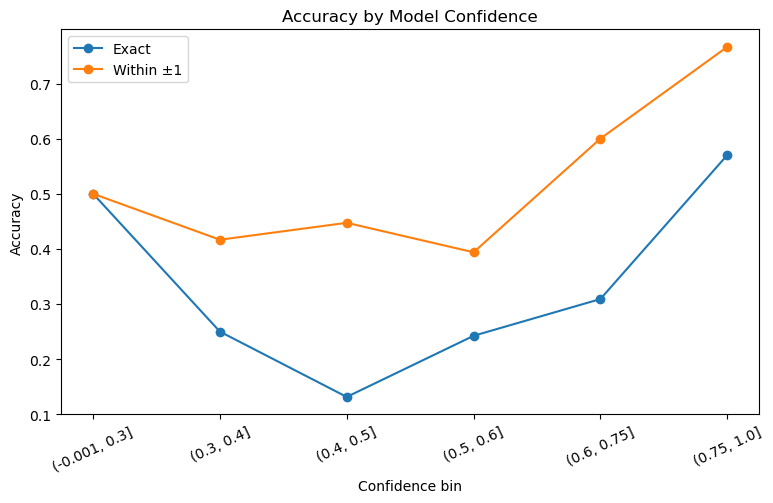

In [48]:
plt.figure(figsize=(9, 5))
plt.plot(np.arange(len(confidence_summary)), confidence_summary["exact_accuracy"], marker="o", label="Exact")
plt.plot(np.arange(len(confidence_summary)), confidence_summary["within_1_round"], marker="o", label="Within ±1")
plt.xticks(np.arange(len(confidence_summary)), confidence_summary.index.astype(str), rotation=25)
plt.title("Accuracy by Model Confidence")
plt.xlabel("Confidence bin")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Part XII — Information-source ablation

## 30. Production vs. scouting text vs. consensus

This experiment answers a stronger question than ordinary feature importance: **how much does each information source improve out-of-time prediction?**

In [50]:
ablation_results = []
ablation_params = {
    "objective": "multi:softprob",
    "num_class": N_CLASSES,
    "eval_metric": "mlogloss",
    "n_estimators": 650,
    "learning_rate": 0.04,
    "max_depth": 4,
    "min_child_weight": 3,
    "subsample": 0.85,
    "colsample_bytree": 0.80,
    "reg_alpha": 0.05,
    "reg_lambda": 2.0,
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
}

for feature_name, feature_cfg in FEATURE_SETS.items():
    cols = columns_for_feature_set(feature_name)
    X_tr = train_df[cols].copy()
    X_te = test_df[cols].copy()

    model = Pipeline([
        ("preprocess", build_preprocessor(
            feature_cfg["numeric"],
            feature_cfg["categorical"],
            include_text=feature_cfg["text"],
        )),
        ("model", XGBClassifier(**ablation_params)),
    ])

    weights = compute_sample_weight(class_weight="balanced", y=y_train)
    model.fit(X_tr, y_train, model__sample_weight=weights)
    proba = align_probability_columns(model.named_steps["model"], model.predict_proba(X_te))
    pred = proba.argmax(axis=1)
    ablation_results.append(classification_metrics(y_test, pred, proba, feature_name))

ablation_table = pd.DataFrame(ablation_results).set_index("model").sort_values(["mean_round_error", "log_loss"])
ablation_table

,exact_accuracy,balanced_accuracy,macro_F1,weighted_F1,log_loss,mean_round_error,within_1_round,within_2_rounds,quadratic_kappa,top_2_accuracy,expected_round_MAE
model,,,,,,,,,,,
production,0.391,0.310,0.299,0.391,1.588,1.137,0.678,0.885,0.770,0.582,1.065
full_predraft,0.423,0.352,0.314,0.372,1.706,1.142,0.667,0.855,0.780,0.661,1.011
production_plus_text,0.372,0.297,0.238,0.313,2.132,1.268,0.582,0.855,0.782,0.555,1.157


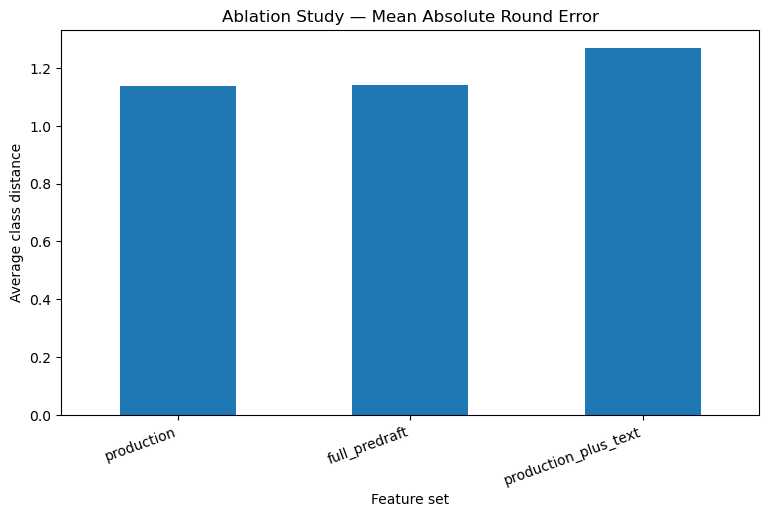

In [51]:
plt.figure(figsize=(9, 5))
ablation_table["mean_round_error"].sort_values().plot(kind="bar")
plt.title("Ablation Study — Mean Absolute Round Error")
plt.xlabel("Feature set")
plt.ylabel("Average class distance")
plt.xticks(rotation=20, ha="right")
plt.show()

# Part XIII — Permutation importance

## 31. Which raw features matter on the future holdout?

Permutation importance measures the deterioration in out-of-time log loss when one raw input column is shuffled.

In [52]:
perm = permutation_importance(
    final_model,
    X_test_full,
    y_test,
    scoring="neg_log_loss",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
perm_df = pd.DataFrame({
    "feature": X_test_full.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)
perm_df.head(30)

,feature,importance_mean,importance_std
282,ovr_rk,0.142,0.039
234,height,0.105,0.010
278,scouting_text_length,0.104,0.018
284,pos_abbr,0.007,0.004
222,college_trend__Sacks,0.006,0.002
285,school,0.005,0.003
19,college_last__Kick Return Touchdowns,0.004,0.001
47,college_last__Sacks,0.003,0.001
114,college_max__Yards Per Reception,0.002,0.002
79,college_max__Kick Returns,0.001,0.000


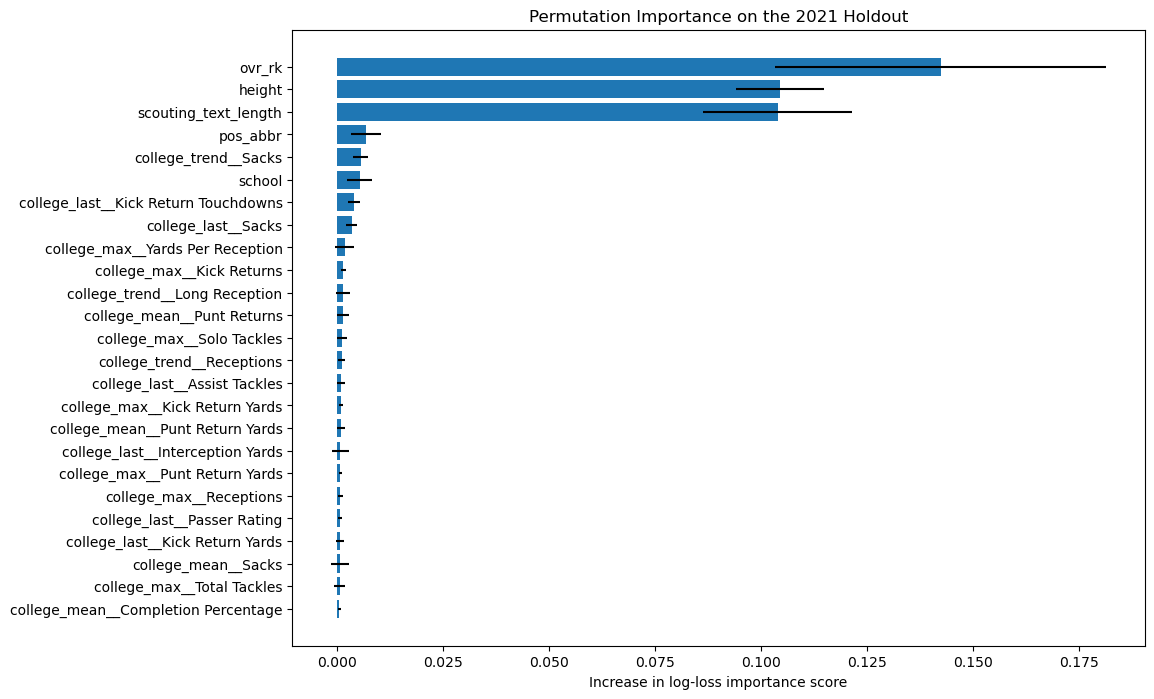

In [53]:
top_perm = perm_df.head(25).sort_values("importance_mean")
plt.figure(figsize=(11, 8))
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
plt.title("Permutation Importance on the 2021 Holdout")
plt.xlabel("Increase in log-loss importance score")
plt.ylabel("")
plt.show()

# Part XIV — Football-specific error analysis

## 32. Performance by position

In [54]:
position_eval = (
    results_2021.groupby("pos_abbr")
    .agg(
        prospects=("player_id", "size"),
        exact_accuracy=("class_distance", lambda x: (x == 0).mean()),
        within_1=("class_distance", lambda x: (x <= 1).mean()),
        mean_round_error=("class_distance", "mean"),
        mean_confidence=("confidence", "mean"),
    )
    .query("prospects >= 5")
    .sort_values("mean_round_error")
)
position_eval

,prospects,exact_accuracy,within_1,mean_round_error,mean_confidence
pos_abbr,,,,,
LS,5,1.000,1.000,0.000,0.871
PK,5,0.800,0.800,0.600,0.765
RB,26,0.577,0.731,0.731,0.787
QB,15,0.600,0.733,0.733,0.895
OG,20,0.550,0.800,0.800,0.791
TE,19,0.579,0.684,1.000,0.780
OLB,17,0.529,0.765,1.059,0.757
WR,58,0.431,0.655,1.121,0.733
DT,25,0.360,0.640,1.200,0.767


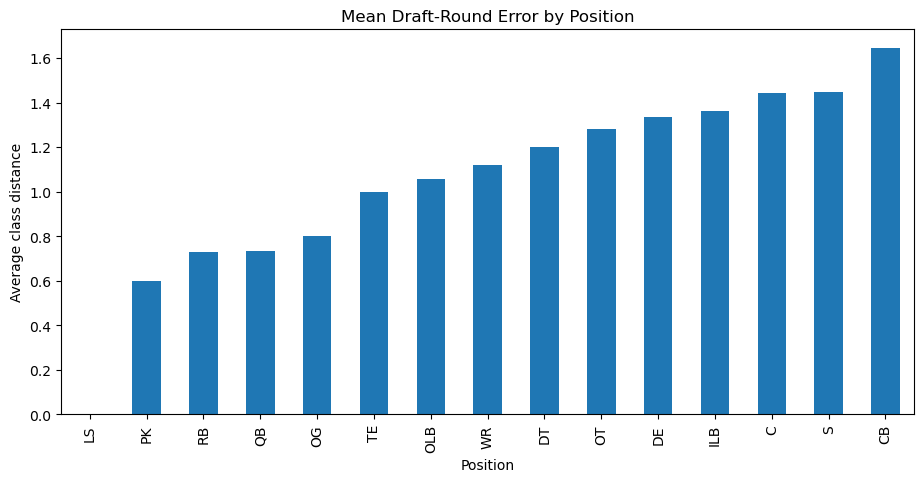

In [55]:
plt.figure(figsize=(11, 5))
position_eval["mean_round_error"].sort_values().plot(kind="bar")
plt.title("Mean Draft-Round Error by Position")
plt.xlabel("Position")
plt.ylabel("Average class distance")
plt.show()

## 33. Performance by actual round / undrafted outcome

In [ ]:
outcome_eval = (
    results_2021.groupby("actual_outcome")
    .agg(
        prospects=("player_id", "size"),
        exact_accuracy=("class_distance", lambda x: (x == 0).mean()),
        within_1=("class_distance", lambda x: (x <= 1).mean()),
        mean_round_error=("class_distance", "mean"),
        mean_confidence=("confidence", "mean"),
    )
    .reindex(CLASS_NAMES)
)
outcome_eval

# Part XV — Cross-validation stability

## 34. Re-evaluate the tuned configuration by development draft class

In [ ]:
cv_rows = []
for train_idx, valid_idx in group_cv.split(X_opt, y_opt, groups_opt):
    X_fold_train = X_opt.iloc[train_idx]
    X_fold_valid = X_opt.iloc[valid_idx]
    y_fold_train = y_opt.iloc[train_idx]
    y_fold_valid = y_opt.iloc[valid_idx]
    held_out_year = int(groups_opt.iloc[valid_idx].iloc[0])

    fold_model = Pipeline([
        ("preprocess", build_preprocessor(full_cfg["numeric"], full_cfg["categorical"], include_text=True)),
        ("model", XGBClassifier(
            **best_params,
            objective="multi:softprob",
            num_class=N_CLASSES,
            eval_metric="mlogloss",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

    fold_weights = compute_sample_weight(class_weight="balanced", y=y_fold_train)
    fold_model.fit(X_fold_train, y_fold_train, model__sample_weight=fold_weights)
    fold_proba = align_probability_columns(
        fold_model.named_steps["model"],
        fold_model.predict_proba(X_fold_valid),
    )
    fold_pred = fold_proba.argmax(axis=1)
    cv_rows.append(classification_metrics(
        y_fold_valid, fold_pred, fold_proba, f"Hold out {held_out_year}"
    ))

cv_stability = pd.DataFrame(cv_rows).set_index("model")
cv_stability

# Part XVI — Multiclass vs. ordinal modeling

## 35. Does explicitly modeling order help?

If the cumulative ordinal model has similar exact accuracy but lower mean round error, higher within-one-round accuracy, or higher quadratic weighted kappa, then the ordered formulation is adding useful structure.

In [ ]:
ordinal_vs_multiclass = pd.DataFrame([
    ordinal_metrics,
    final_metrics,
]).set_index("model")
ordinal_vs_multiclass

# Part XVII — Export model and predictions

## 36. Save the full fitted pipeline

The serialized pipeline preserves numeric preprocessing, category encoding, TF-IDF vocabulary, SVD projection, and the tuned XGBoost classifier.

In [ ]:
import joblib

MODEL_PATH = Path("nfl_draft_round_xgb_pipeline.joblib")
PREDICTIONS_PATH = Path("nfl_draft_round_2021_predictions.csv")

joblib.dump(final_model, MODEL_PATH)
results_2021.sort_values(["predicted_target", "confidence"], ascending=[True, False]).to_csv(
    PREDICTIONS_PATH,
    index=False,
)

print("Saved model:", MODEL_PATH.resolve())
print("Saved predictions:", PREDICTIONS_PATH.resolve())

# 37. Interpretation checklist

After running the notebook, answer these questions rather than reporting only one accuracy number.

### Predictive performance
- What percentage of prospects are placed in the exact correct round?
- What percentage are within one round?
- What is the average ordinal error?
- How much better is the tuned model than the prior-probability baseline?

### Modeling choices
- Does cumulative ordinal XGBoost improve ordinal metrics over ordinary multiclass XGBoost?
- Does Bayesian optimization materially improve grouped validation and the 2021 holdout?
- Are results stable across development years?

### Information value
- How far can college production and physical profile go alone?
- Does scouting-report NLP improve prediction?
- How much additional predictive power comes from ESPN grade and rank?

### Football interpretation
- Which positions are easiest and hardest to project?
- Which rounds are easiest and hardest?
- Which 2021 prospects were the largest disagreements between the public-data model and the actual NFL Draft?

### Probability quality
- Are high-confidence predictions actually more accurate?
- Which prospects have the highest uncertainty?
- Is expected-round prediction useful even when the modal class is wrong?

# 38. Limitations

The public files do not contain every piece of information available to NFL clubs. Important omitted variables may include:

- complete medical evaluations
- combine / pro-day measurements not present here
- interviews and psychological assessments
- private team scouting grades
- scheme fit
- roster needs
- positional scarcity
- draft-day trades
- late injury/news information

The model should therefore be interpreted as a **public-information estimate of draft round**, not a reconstruction of every factor used by an NFL front office.

# 39. Portfolio summary

A concise interview or résumé description:

> **Built an end-to-end NFL draft-round prediction system using multi-season college production, physical measurements, advanced QBR, and scouting-report NLP. Engineered longitudinal player features, implemented leakage-safe mixed-data preprocessing and class-imbalance handling, compared multiclass and custom ordinal gradient-boosting approaches, tuned XGBoost with Bayesian optimization under draft-year grouped validation, and evaluated probabilistic predictions on an untouched future draft class.**

This project demonstrates data engineering, statistical reasoning, NLP, ordinal modeling, model optimization, interpretability, and sports-domain analysis in one coordinated workflow.